# Grid System Demo

This notebook demonstrates the new grid system for organizing stellar objects and creating evolution diagrams.

In [1]:
import matplotlib.pyplot as plt
from rua.canvas import setup_canvas
from rua.grid import Grid
from rua.components.stellar import star
from rua.components.binary import binary
from rua.components.compact import white_dwarf, neutron_star, black_hole
from rua.utils.colors import colors

## Basic Grid Example

Create a simple 2x3 grid with stars at different evolutionary stages.

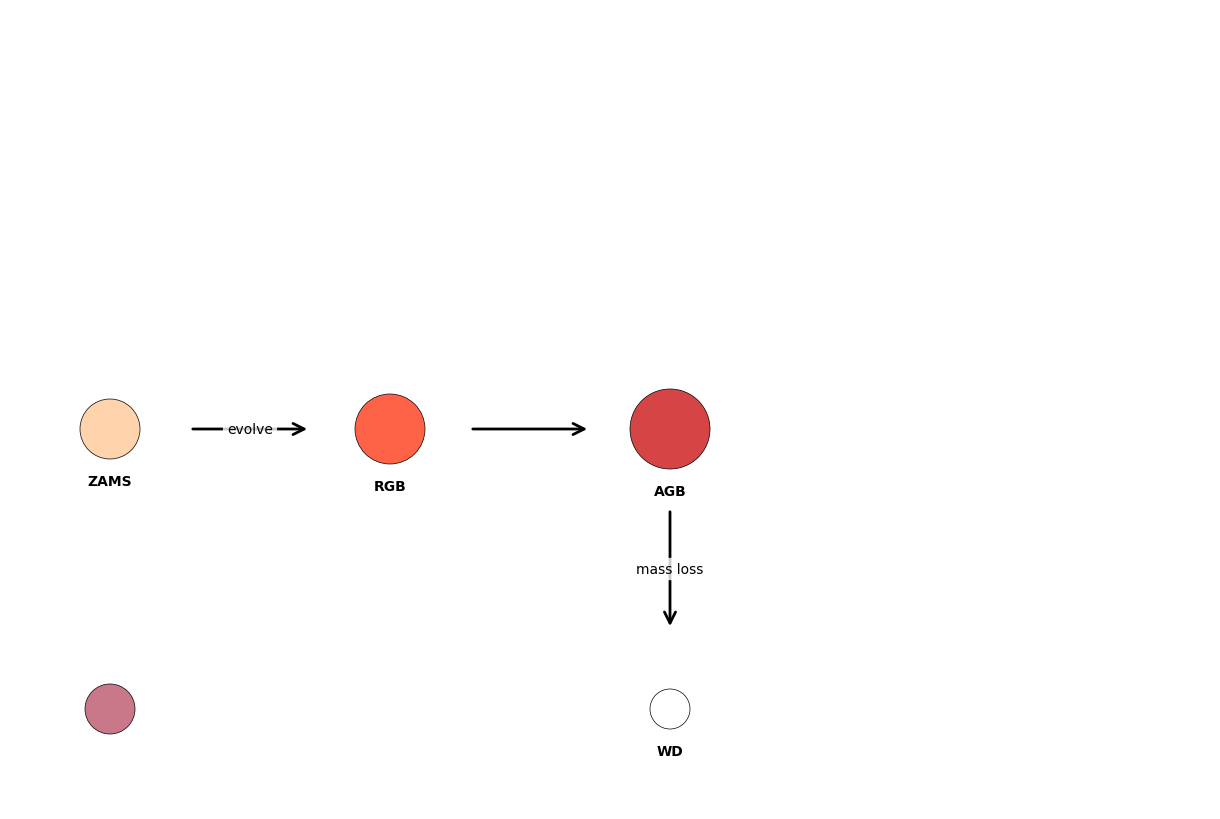

In [2]:
# Create canvas and grid
fig, ax = setup_canvas(width=12, height=8)
grid = Grid(rows=2, cols=3, cell_width=2.0, cell_height=2.0, padding=0.8, ax=ax)

# Add stars to grid positions
grid.add_element(0, 0, star, size=0.3, color=colors['ZAMS'], label_text='ZAMS')
grid.add_element(0, 1, star, size=0.35, color=colors['RGB'], label_text='RGB')
grid.add_element(0, 2, star, size=0.4, color=colors['AGB'], label_text='AGB')
grid.add_element(1, 0, star, size=0.25, color=colors['lower_mass_ZAMS'])
grid.add_element(1, 2, white_dwarf, size=0.2, label_text='WD')

# Add evolution arrows
grid.add_connection(0, 0, 0, 1, label='evolve')
grid.add_connection(0, 1, 0, 2)
grid.add_connection(0, 2, 1, 2, label='mass loss')

# Render
grid.render()
plt.show()

## Binary Evolution Grid

Show the evolution of a binary system through different phases.

#ffd3ac
#FF6347
#ffd3ac
#ffd3ac


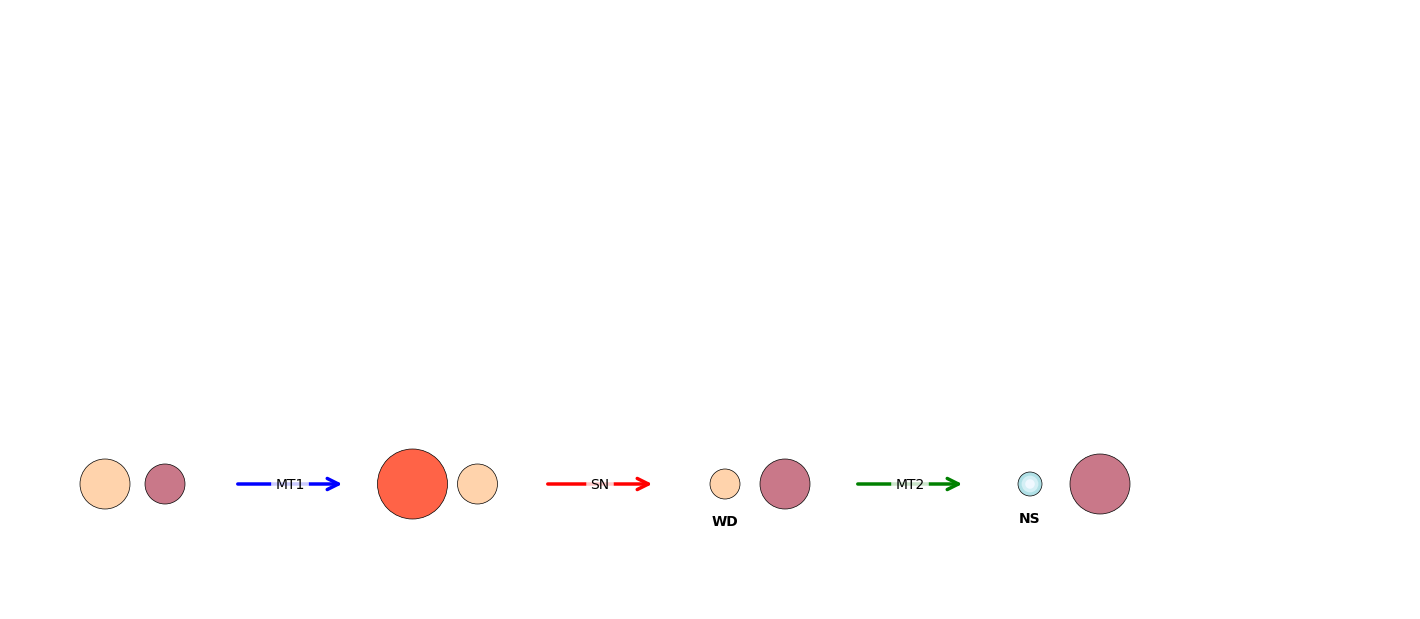

In [3]:
fig, ax = setup_canvas(width=14, height=6)
grid = Grid(rows=1, cols=4, cell_width=2.5, cell_height=2.5, padding=0.6, ax=ax)

# Stage 1: Initial ZAMS binary
grid.add_element(0, 0, binary,
                primary=star,
                secondary=star,
                size_primary=0.25,
                size_secondary=0.2,
                separation=0.6,
                colors_tuple=(colors['ZAMS'], colors['lower_mass_ZAMS']))

# Stage 2: After first mass transfer
grid.add_element(0, 1, binary,
                primary=star,
                secondary=star,
                size_primary=0.35,
                size_secondary=0.2,
                separation=0.65,
                colors_tuple=(colors['RGB'], colors['ZAMS']))

# Stage 3: After supernova
grid.add_element(0, 2, binary,
                primary=white_dwarf,
                secondary=star,
                size_primary=0.15,
                size_secondary=0.25,
                separation=0.6)

# Stage 4: After second mass transfer
grid.add_element(0, 3, binary,
                primary=neutron_star,
                secondary=star,
                size_primary=0.12,
                size_secondary=0.3,
                separation=0.7)

# Add evolution arrows with labels
grid.add_connection(0, 0, 0, 1, label='MT1', color='blue', linewidth=2.5)
grid.add_connection(0, 1, 0, 2, label='SN', color='red', linewidth=2.5)
grid.add_connection(0, 2, 0, 3, label='MT2', color='green', linewidth=2.5)

grid.render()
plt.show()

## 8-Direction Arrow System

Demonstrate arrows in all 8 directions (N, NE, E, SE, S, SW, W, NW).

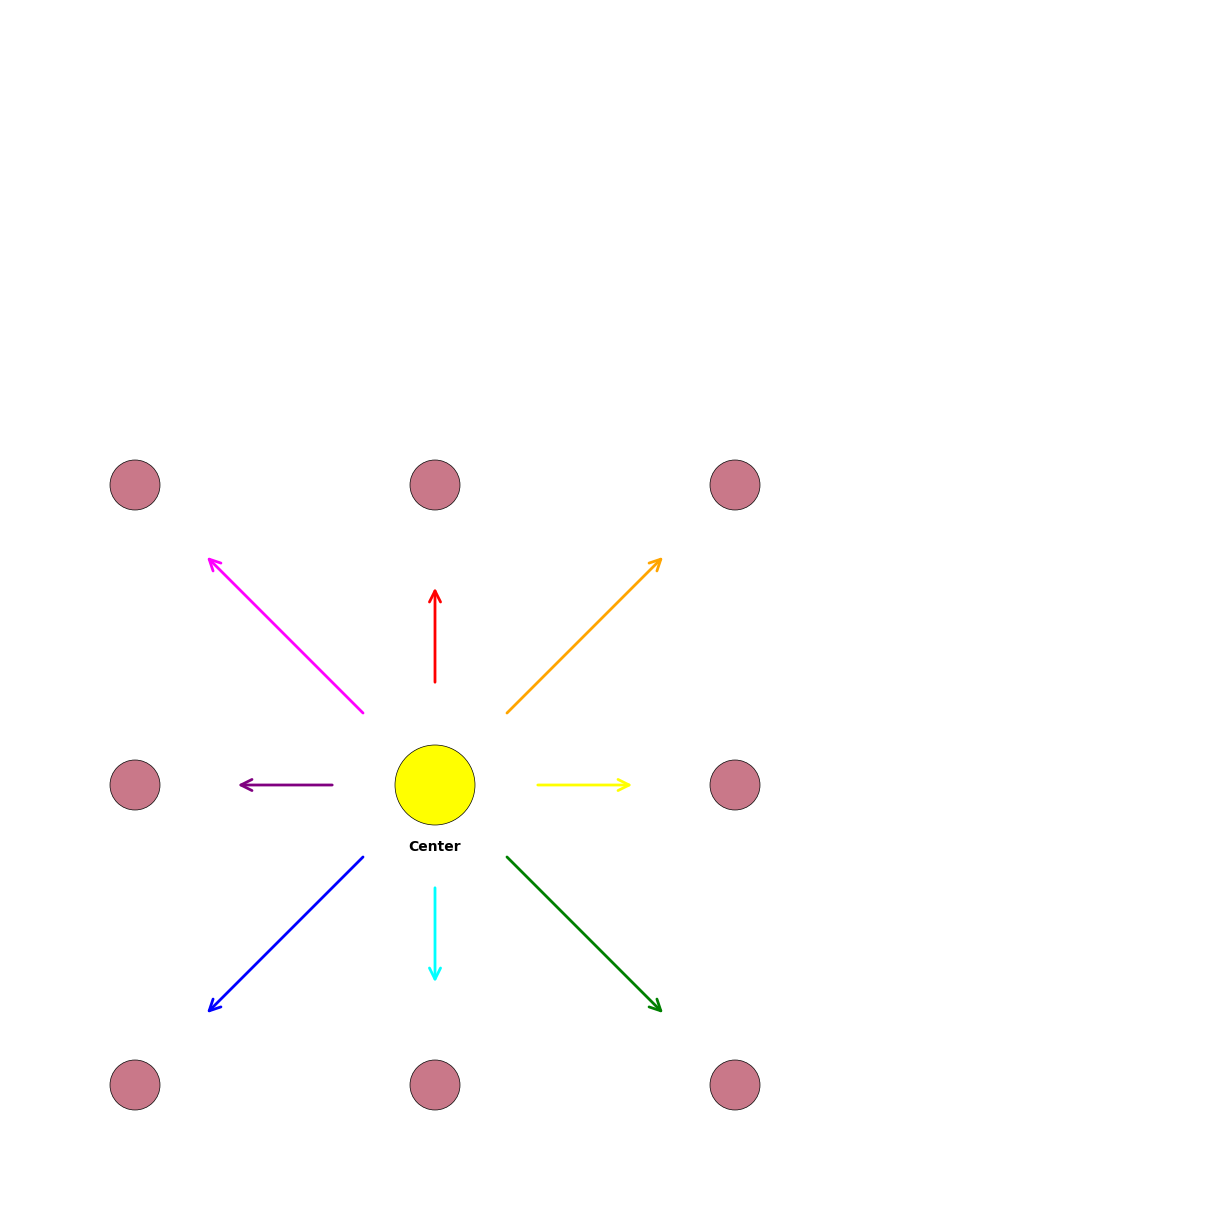

In [4]:
fig, ax = setup_canvas(width=12, height=12)
grid = Grid(rows=3, cols=3, cell_width=2.5, cell_height=2.5, padding=0.5, ax=ax)

# Center star
grid.add_element(1, 1, star, size=0.4, color='yellow', label_text='Center')

# Surrounding stars in all 8 directions
grid.add_element(0, 1, star, size=0.25, color=colors['lower_mass_ZAMS'])  # N
grid.add_element(0, 2, star, size=0.25, color=colors['lower_mass_ZAMS'])  # NE
grid.add_element(1, 2, star, size=0.25, color=colors['lower_mass_ZAMS'])  # E
grid.add_element(2, 2, star, size=0.25, color=colors['lower_mass_ZAMS'])  # SE
grid.add_element(2, 1, star, size=0.25, color=colors['lower_mass_ZAMS'])  # S
grid.add_element(2, 0, star, size=0.25, color=colors['lower_mass_ZAMS'])  # SW
grid.add_element(1, 0, star, size=0.25, color=colors['lower_mass_ZAMS'])  # W
grid.add_element(0, 0, star, size=0.25, color=colors['lower_mass_ZAMS'])  # NW

# Arrows in all directions with different colors
grid.add_connection(1, 1, 0, 1, color='red')      # to N
grid.add_connection(1, 1, 0, 2, color='orange')   # to NE
grid.add_connection(1, 1, 1, 2, color='yellow')   # to E
grid.add_connection(1, 1, 2, 2, color='green')    # to SE
grid.add_connection(1, 1, 2, 1, color='cyan')     # to S
grid.add_connection(1, 1, 2, 0, color='blue')     # to SW
grid.add_connection(1, 1, 1, 0, color='purple')   # to W
grid.add_connection(1, 1, 0, 0, color='magenta')  # to NW

grid.render()
plt.show()

## Custom Arrow Directions

You can also specify custom arrow directions explicitly.

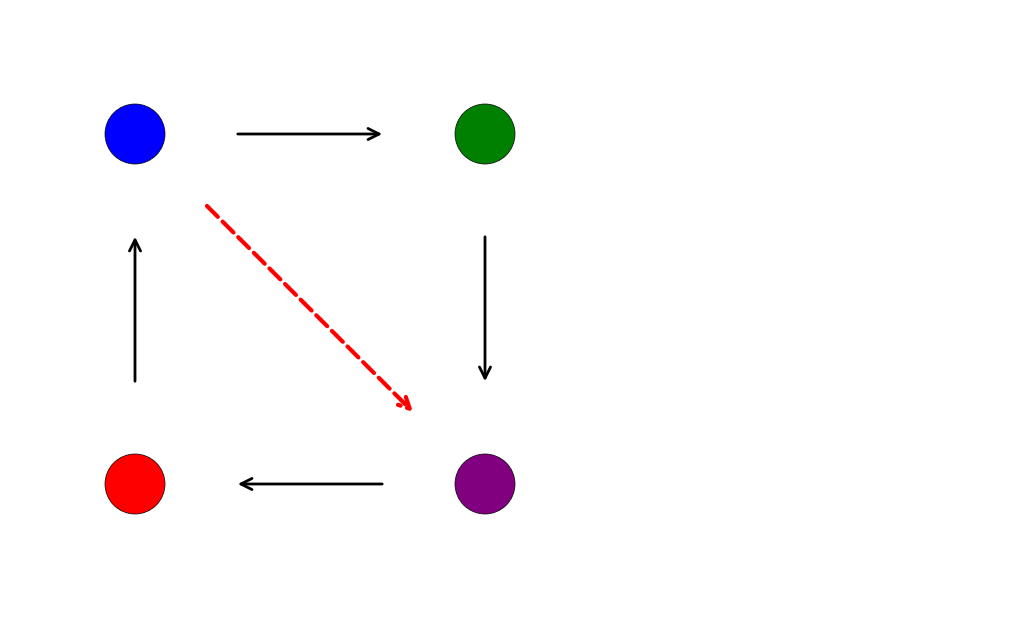

In [5]:
fig, ax = setup_canvas(width=10, height=6)
grid = Grid(rows=2, cols=2, cell_width=2.5, cell_height=2.5, padding=1.0, ax=ax)

# Add some stars
grid.add_element(0, 0, star, size=0.3, color='blue')
grid.add_element(0, 1, star, size=0.3, color='green')
grid.add_element(1, 0, star, size=0.3, color='red')
grid.add_element(1, 1, star, size=0.3, color='purple')

# Custom arrow directions
grid.add_connection(0, 0, 0, 1, from_direction='E', to_direction='W', color='black')
grid.add_connection(0, 1, 1, 1, from_direction='S', to_direction='N', color='black')
grid.add_connection(1, 1, 1, 0, from_direction='W', to_direction='E', color='black')
grid.add_connection(1, 0, 0, 0, from_direction='N', to_direction='S', color='black')

# Diagonal with custom directions
grid.add_connection(0, 0, 1, 1, from_direction='SE', to_direction='NW', 
                   color='red', linestyle='dashed', linewidth=3)

grid.render()
plt.show()

## Method Chaining

The Grid class supports method chaining for a more fluent API.

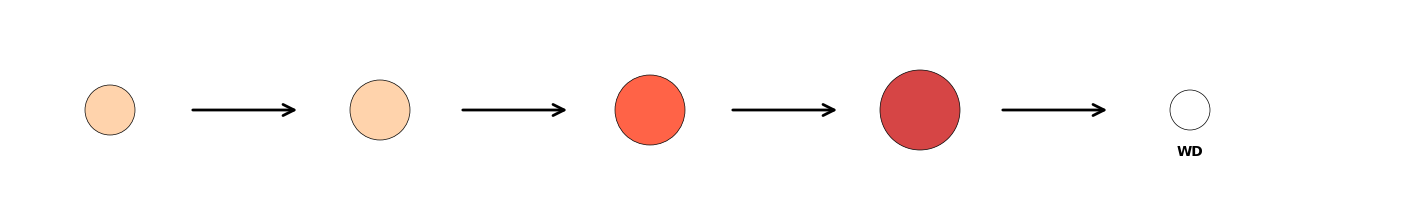

In [9]:
fig, ax = setup_canvas(width=14, height=2)

# Chain all operations together
(Grid(rows=1, cols=5, cell_width=2.0, cell_height=2.0, padding=0.7, ax=ax)
 .add_element(0, 0, star, size=0.25, color=colors['ZAMS'])
 .add_element(0, 1, star, size=0.3, color=colors['ZAMS'])
 .add_element(0, 2, star, size=0.35, color=colors['RGB'])
 .add_element(0, 3, star, size=0.4, color=colors['AGB'])
 .add_element(0, 4, white_dwarf, size=0.2)
 .add_connection(0, 0, 0, 1)
 .add_connection(0, 1, 0, 2)
 .add_connection(0, 2, 0, 3)
 .add_connection(0, 3, 0, 4)
 .render())

plt.show()